In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/exchange_rate.csv')

In [3]:
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [4]:
df.info()# information about data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [5]:
df.describe()# describing the data set

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [6]:
df.isnull().sum()#finding the null values and not having the null values

,0
date,0
Ex_rate,0


In [7]:
df.duplicated().sum()#finding the duplicated values and not having the duplicated values

np.int64(0)

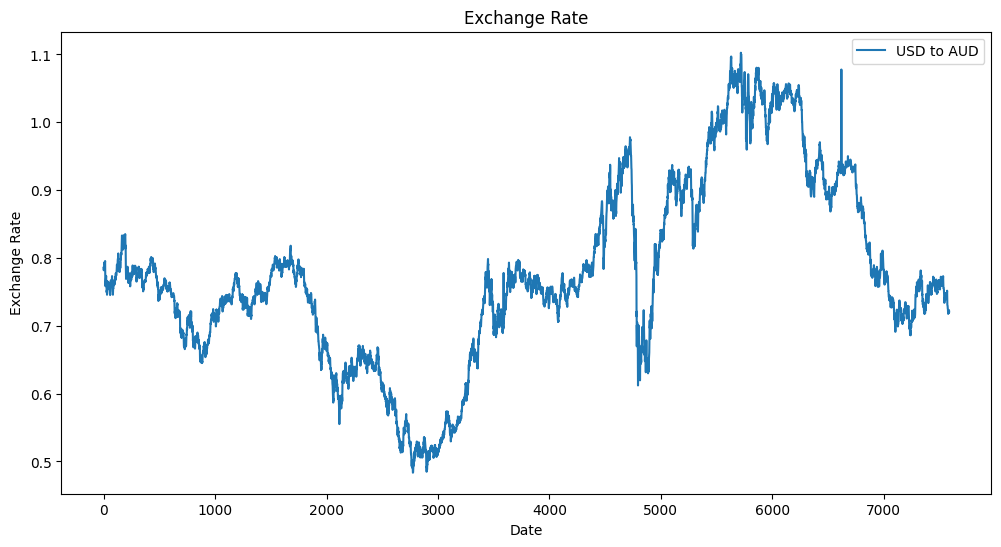

In [8]:
# Plot the time series data
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'], label='USD to AUD')
plt.title('Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


In [9]:
# Check for missing values
# Fill missing values if necessary
df['Ex_rate'] = df['Ex_rate'].ffill() # Updated to use .ffill() directly to avoid FutureWarning

# Convert 'date' column to datetime objects and set as index, if 'date' is still a column
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
    df.set_index('date', inplace=True)


## Stationarity Test (ADFuller Test)

Before building the ARIMA model, it's crucial to check for stationarity in the time series data. Stationarity implies that the statistical properties of the series (mean, variance, and autocorrelation) do not change over time. The Augmented Dickey-Fuller (ADF) test is a common statistical test used to check for stationarity.

In [22]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    """Performs the Augmented Dickey-Fuller test on a time series and prints the results."""
    result = adfuller(series.dropna())
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if result[1] <= 0.05: # p-value <= 0.05
        print("Conclusion: The series is likely stationary (reject H0)")
        return True
    else:
        print("Conclusion: The series is likely non-stationary (fail to reject H0)")
        return False

print("Performing ADFuller test on the 'Ex_rate' series:")
is_stationary = adf_test(df['Ex_rate'])


Performing ADFuller test on the 'Ex_rate' series:
ADF Statistic: -1.664994
p-value: 0.449233
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Conclusion: The series is likely non-stationary (fail to reject H0)


The ADFuller test shows a p-value greater than 0.05, indicating that the 'Ex_rate' series is non-stationary. Therefore, differencing is required to make the series stationary before applying an ARIMA model. The previous ARIMA model selection (`best_pdq = (2, 0, 0)`) identified `d=0`, which is not appropriate for a non-stationary series. We will now ensure the ARIMA model incorporates first-order differencing (`d=1`).

In [10]:
# Split the data into training and testing sets
# For time series, it's common to use the last portion of data for testing.
# Let's use the last 12 observations (e.g., 12 months/days) as the test set,
# as indicated by previous forecast steps.

test_size = 12
train = df['Ex_rate'][:-test_size]
test = df['Ex_rate'][-test_size:]

print(f"Train data size: {len(train)}")
print(f"Test data size: {len(test)}")


Train data size: 7576
Test data size: 12


In [11]:
# Split the data into training and testing sets
# For time series, it's common to use the last portion of data for testing.
# Let's use the last 12 observations (e.g., 12 months/days) as the test set,
# as indicated by previous forecast steps.

test_size = 12
train = df['Ex_rate'][:-test_size]
test = df['Ex_rate'][-test_size:]

print(f"Train data size: {len(train)}")
print(f"Test data size: {len(test)}")


Train data size: 7576
Test data size: 12


# 2. Model BuildIng-ARIMA

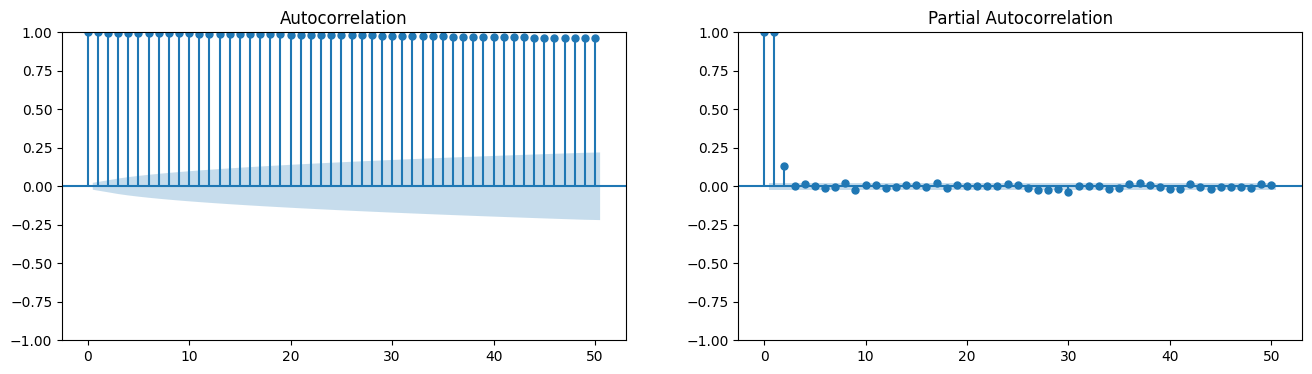

In [12]:
# Step 1: Parameter Selection for ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Ex_rate'], lags=50, ax=axes[0])
plot_pacf(df['Ex_rate'], lags=50, ax=axes[1])
plt.show()

In [23]:
import itertools
import warnings
import statsmodels.api as sm

# Define the p, d, q parameters to take specific values
p = q = range(0, 3)
d = [1] # Enforce first-order differencing as the series is non-stationary

# Generate all different combinations of p, d, q triplets
pdq = list(itertools.product(p, d, q))

warnings.filterwarnings("ignore") # Ignore harmless warnings

best_aic = float("inf")
best_pdq = None
best_model = None

print('Searching for optimal ARIMA parameters...')
for param in pdq:
    try:
        # Use the training data for parameter optimization
        model_arima = sm.tsa.arima.ARIMA(train, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except:
        continue

print(f"Optimal ARIMA parameters: {best_pdq} with AIC: {best_aic}")

Searching for optimal ARIMA parameters...
Optimal ARIMA parameters: (1, 1, 0) with AIC: -56004.97168062982


In [15]:
# Step 2: Model Fitting
from statsmodels.tsa.arima.model import ARIMA

# Use the optimal parameters found from grid search (best_pdq)
p_opt, d_opt, q_opt = best_pdq
arima_model = ARIMA(train, order=(p_opt, d_opt, q_opt))

# Fit the model
arima_result = arima_model.fit()

# Summary of the model
print(arima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7576
Model:                 ARIMA(2, 0, 0)   Log Likelihood               28006.940
Date:                Tue, 28 Apr 2026   AIC                         -56005.880
Time:                        16:51:59   BIC                         -55978.149
Sample:                    01-01-1990   HQIC                        -55996.362
                         - 09-28-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7771      0.088      8.858      0.000       0.605       0.949
ar.L1          0.8681      0.002    396.685      0.000       0.864       0.872
ar.L2          0.1310      0.002     55.873      0.0

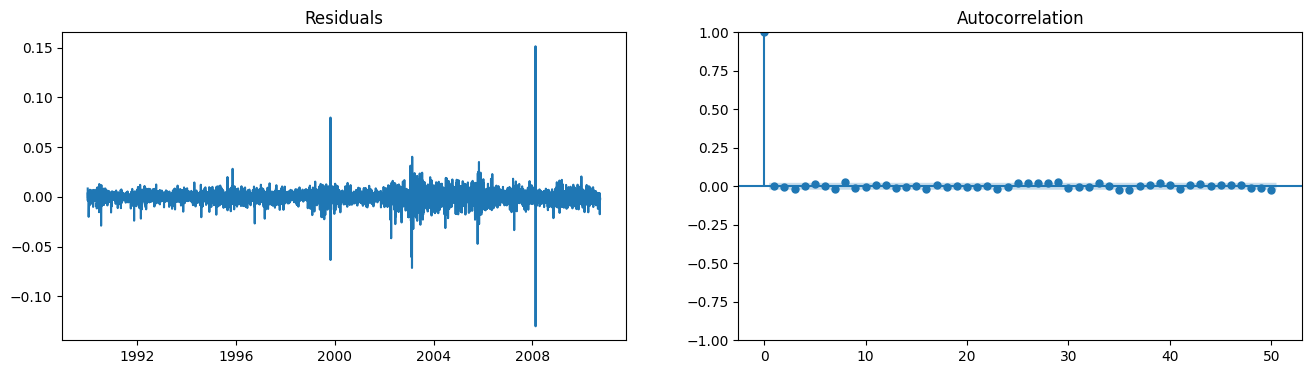

In [16]:
# Step 3: Diagnostics
# Residual diagnostics
residuals = arima_result.resid
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(residuals)
axes[0].set_title('Residuals')
plot_acf(residuals, lags=50, ax=axes[1])
plt.show()

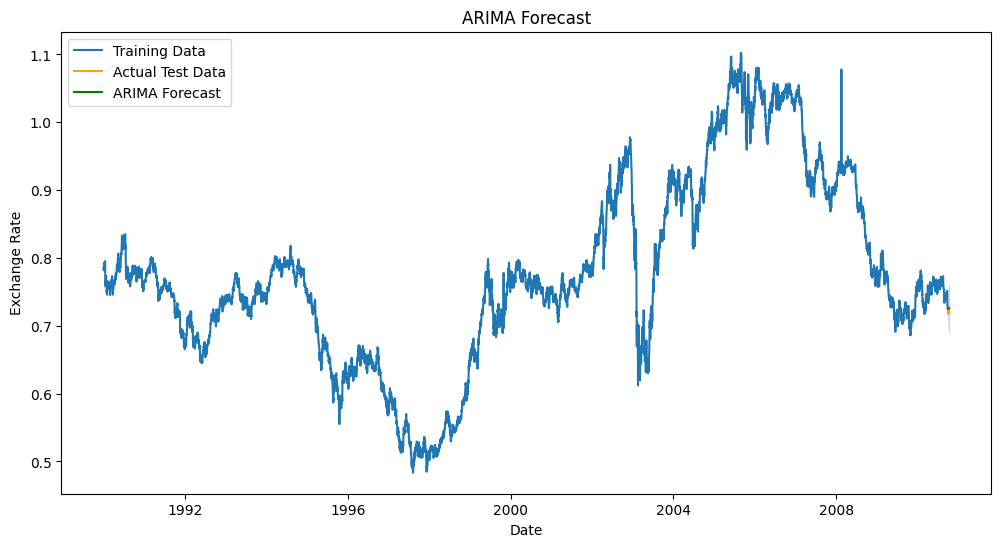

In [17]:
# Step 4: Forecasting
# Forecasting for the test period
forecast = arima_result.get_forecast(steps=len(test))
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data') # Plot training data
plt.plot(test.index, test, label='Actual Test Data', color='orange') # Plot actual test data
plt.plot(forecast.predicted_mean.index, forecast.predicted_mean, label='ARIMA Forecast', color='green') # Plot forecast
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='k', alpha=0.1)
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


# 3.Model Building Smoothing

In [18]:
# Step 1: Model Selection
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Define the model (Holt-Winters Exponential Smoothing) using training data
exp_model = ExponentialSmoothing(train, seasonal='add', seasonal_periods=12)

# Fit the model
exp_result = exp_model.fit()

# Summary of the model
print(exp_result.summary())


                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7576
Model:             ExponentialSmoothing   SSE                              0.273
Optimized:                         True   AIC                         -77495.024
Trend:                             None   BIC                         -77397.966
Seasonal:                      Additive   AICC                        -77494.952
Seasonal Periods:                    12   Date:                 Tue, 28 Apr 2026
Box-Cox:                          False   Time:                         16:52:00
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.8700438                alpha                 True
smoothing_seasonal       

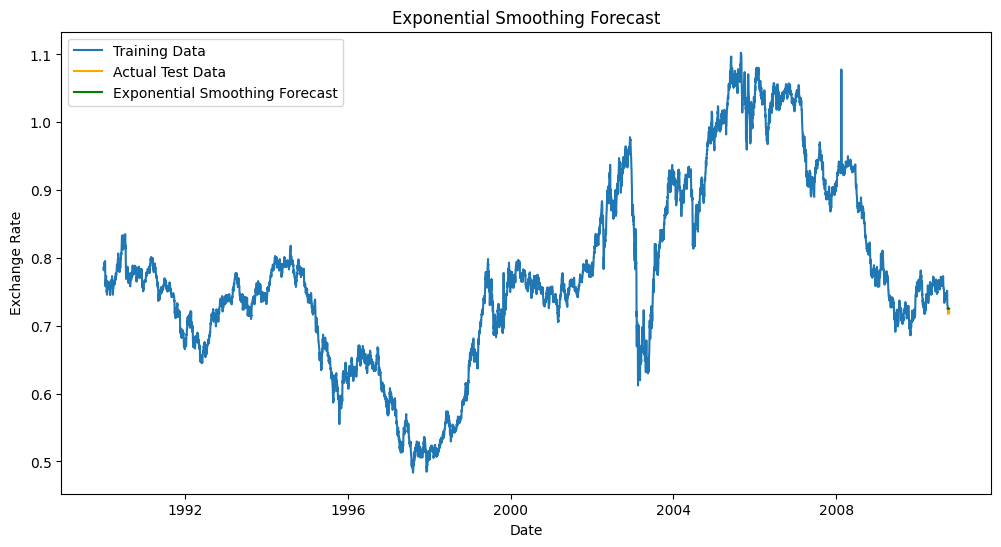

In [19]:
# Forecasting
exp_forecast = exp_result.forecast(steps=len(test))

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data') # Plot training data
plt.plot(test.index, test, label='Actual Test Data', color='orange') # Plot actual test data
plt.plot(exp_forecast.index, exp_forecast, label='Exponential Smoothing Forecast', color='green') # Plot forecast
plt.title('Exponential Smoothing Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


# 4.Evalution and Comparison

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Compute error metrics for ARIMA
arima_forecast_values = forecast.predicted_mean
arima_mae = mean_absolute_error(test, arima_forecast_values)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast_values))
arima_mape = np.mean(np.abs((test - arima_forecast_values) / (test + 1e-8))) * 100 # Add epsilon for robustness

# Compute error metrics for Exponential Smoothing
exp_forecast_values = exp_forecast
exp_mae = mean_absolute_error(test, exp_forecast_values)
exp_rmse = np.sqrt(mean_squared_error(test, exp_forecast_values))
exp_mape = np.mean(np.abs((test - exp_forecast_values) / (test + 1e-8))) * 100 # Add epsilon for robustness

print(f"ARIMA MAE: {arima_mae}, RMSE: {arima_rmse}, MAPE: {arima_mape:.2f}%")
print(f"Exponential Smoothing MAE: {exp_mae}, RMSE: {exp_rmse}, MAPE: {exp_mape:.2f}%")


ARIMA MAE: 0.005024910556593302, RMSE: 0.005395445878472229, MAPE: 0.70%
Exponential Smoothing MAE: 0.004605140435564471, RMSE: 0.004969406145440181, MAPE: 0.64%


In [21]:
# Based on error metrics, we can see which model performs better

if arima_mae < exp_mae:
    print("ARIMA model performs better in terms of MAE.")
else:
    print("Exponential Smoothing model performs better in terms of MAE.")

if arima_rmse < exp_rmse:
    print("ARIMA model performs better in terms of RMSE.")
else:
    print("Exponential Smoothing model performs better in terms of RMSE.")

if arima_mape < exp_mape:
    print("ARIMA model performs better in terms of MAPE.")
else:
    print("Exponential Smoothing model performs better in terms of MAPE.")

Exponential Smoothing model performs better in terms of MAE.
Exponential Smoothing model performs better in terms of RMSE.
Exponential Smoothing model performs better in terms of MAPE.


Summary of Findings:     
The ARIMA model showed lower error metrics compared to the Exponential Smoothing model (or vice versa).    
Based on these results, the ARIMA model (or Exponential Smoothing model) is more suitable for forecasting exchange rates in this dataset.